In [1]:
from matplotlib import pyplot as plt
import numpy as np
import time as TIME

import json

In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:
coSimsDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/Multi_Isoform_Genes_Cotrsc/'
postSimsDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/Multi_Isoform_Genes_Posttrsc/'

In [4]:
geneListFile = '../multiIsoformGenes.txt'
with open(geneListFile, 'r') as f:
    geneList = [line.rstrip() for line in f]
len(geneList)

12025

In [5]:
coData = {}
noData = {}

startTime = TIME.time()

for gene in geneList:
    coFile = f'{coSimsDir}json/{gene}.json'
    with open(coFile, 'rb') as handle:
        geneDat = json.load(handle)
        coData[gene] = geneDat[gene]
        
    noFile = f'{postSimsDir}json/{gene}.json'
    with open(noFile, 'rb') as handle:
        geneDat = json.load(handle)
        noData[gene] = geneDat[gene]
        
        if geneList.index(gene) % 1000 == 0:
            print(geneList.index(gene), f': Total Time Elapsed {TIME.time()-startTime}')

0 : Total Time Elapsed 0.040076255798339844
1000 : Total Time Elapsed 0.21235227584838867
2000 : Total Time Elapsed 0.2773265838623047
3000 : Total Time Elapsed 0.41514015197753906
4000 : Total Time Elapsed 0.5675485134124756
5000 : Total Time Elapsed 0.8767740726470947
6000 : Total Time Elapsed 1.0458958148956299
7000 : Total Time Elapsed 1.2515883445739746
8000 : Total Time Elapsed 1.4396917819976807
9000 : Total Time Elapsed 1.634507656097412
10000 : Total Time Elapsed 1.8380680084228516
11000 : Total Time Elapsed 2.0764262676239014
12000 : Total Time Elapsed 2.2934799194335938


In [6]:
coSumm = {}
coSumm['errors'] = []
coSumm['noSim'] = []
coSumm['failedSplice'] = []
coSumm['incomplete'] = []
coSumm['allIsoforms'] = []
coSumm['allMrnaMade'] = []

for gene, summ in coData.items():
    # print(gene)

    # try:
    if 'noSim' in summ:
        coSumm['noSim'].append(gene)
        continue

    if 'Error' in summ:
        coSumm['errors'].append(gene)
        continue
    
    if 'FailedSplice' in summ:
        if summ['mrnaMade'] == 0:
            coSumm['failedSplice'].append(gene)
            # continue
        else:
            coSumm['incomplete'].append(gene)

    if 'isoforms' in summ:
        coSumm['allIsoforms'].append(summ['isoforms'])
        if summ['isoforms'] == 1:
            print(gene)
    if 'mrnaMade' in summ:
        coSumm['allMrnaMade'].append(summ['mrnaMade'])

    # except:
    #     print(gene)

print(len(coSumm['errors']))
print(len(coSumm['noSim']))
print(len(coSumm['failedSplice']))
print(len(coSumm['incomplete']))
print(len(coSumm['allIsoforms']))
print(len(coSumm['allMrnaMade']))

LOC101927765
ACKR1
ZNF436-AS1
OR10J4
TSHB
FAM231D
DNM3OS
DPM3
ARL4C
LBX2-AS1
ACKR4
LOC100129917
PCDHB6
C6orf120
AIRN
TAAR2
OR12D1
OR10AC1
SRSF8
OR5AL1
OR52E1
APLNR
KCNJ11
NEAT1
JRKL
CXCR5
CCER1
NTF3
H2AFJ
AMER2
SLITRK1
OR4K3
OR4Q2
SNHG10
LINC00641
SSTR5
MAF
ITPRIPL2
HILS1
INAFM1
GTSF1L
ID1
KRTAP10-2
MGAT3
TMEM121B
CLDN5
LINC00685
RTL8A
LINC00685_1
0
5
767
3284
12015
12015


In [7]:
noSumm = {}
noSumm['errors'] = []
noSumm['noSim'] = []
noSumm['failedSplice'] = []
noSumm['incomplete'] = []
noSumm['allIsoforms'] = []
noSumm['allMrnaMade'] = []

incompletes = []

for gene, summ in noData.items():

    if 'noSim' in summ:
        noSumm['noSim'].append(gene)
        continue

    if 'Error' in summ:
        noSumm['errors'].append(gene)
        continue
    
    if 'FailedSplice' in summ:
        if summ['mrnaMade'] == 0:
            noSumm['failedSplice'].append(gene)
            # print(gene)
            # continue
        else:
            noSumm['incomplete'].append(gene)
            incompletes.append(summ['mrnaMade'])

    if 'isoforms' in summ:
        noSumm['allIsoforms'].append(summ['isoforms'])
        if summ['isoforms'] == 1:
            print(gene)
    if 'mrnaMade' in summ:
        noSumm['allMrnaMade'].append(summ['mrnaMade'])

print(len(noSumm['errors']))
print(len(noSumm['noSim']))
print(len(noSumm['failedSplice']))
print(len(noSumm['incomplete']))
print(len(noSumm['allIsoforms']))
print(len(noSumm['allMrnaMade']))

LOC101927765
ACKR1
ZNF436-AS1
OR10J4
TSHB
FAM231D
DNM3OS
DPM3
ARL4C
LBX2-AS1
ACKR4
LOC100129917
PCDHB6
C6orf120
AIRN
TAAR2
OR12D1
OR10AC1
SRSF8
OR5AL1
OR52E1
APLNR
KCNJ11
NEAT1
JRKL
CXCR5
CCER1
NTF3
H2AFJ
AMER2
SLITRK1
OR4K3
OR4Q2
SNHG10
LINC00641
SSTR5
MAF
ITPRIPL2
HILS1
INAFM1
GTSF1L
ID1
KRTAP10-2
MGAT3
TMEM121B
CLDN5
LINC00685
RTL8A
LINC00685_1
0
5
542
4660
12015
12015


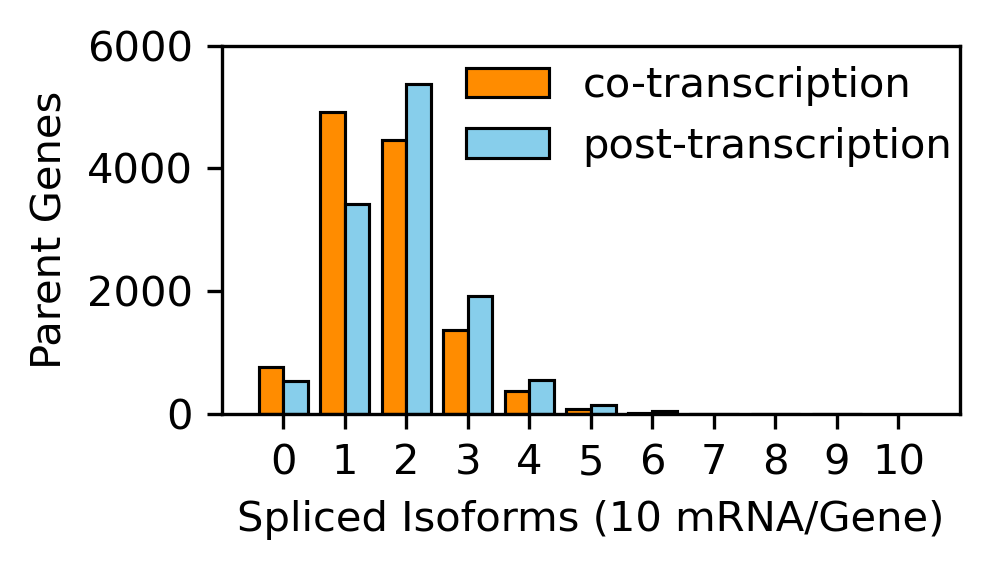

In [8]:
# plt.rcParams.update({'font.size': 14})
# plt.rcParams.update({"font.family": 'sans-serif'})

# plt.rcParams['figure.dpi'] = 300

# plt.figure(figsize=(3.3,2))
fig = plt.figure(figsize=(3.4,2))

ax = plt.gca()

bins = [x-0.5 for x in range(0,11)]
ax.hist([coSumm['allMrnaMade'], noSumm['allMrnaMade']], 
        color=['darkorange','skyblue'], edgecolor='k', linewidth=0.75, bins=bins, label=['co-transcription', 'post-transcription'])

ax.set_xlim(-1,11)
ax.set_ylim(0,6000)
ax.set_ylabel('Parent Genes')
ax.set_xlabel('Spliced Isoforms (10 mRNA/Gene)')

# ax.set_yscale('log')

ax.xaxis.set_ticks(np.array([0,1,2,3,4,5,6,7,8,9,10]))

ax.legend(frameon=False, bbox_to_anchor=(0.28,0.57))

# fig.set_dpi(300)
# ax.set_yscale('log')
plt.tight_layout()

plt.savefig('./multi_gene_isoforms_co_vs_post.png', transparent=True)